# Analysis Experiments

In [1]:
import pickle
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import jensenshannon, cdist

## Load Data

In [37]:
agent_map_f = [
    "F only",
    "... → E (Progressive)",
    "... → F (Progressive)",
    "... → E (Tuned)",
    "... → F (Tuned)"
]

agent_map_g = [
    "G only",
    "... → F (Progressive)",
    "... → G (Progressive)",
    "... → F (Tuned)",
    "... → G (Tuned)"
]

with open("../trajs/regf_trajs_indist_enc1.pkl",'rb') as f:
    df_f_indist: pd.DataFrame = pickle.load(f)
with open("../trajs/regf_trajs_outofdist_enc1.pkl",'rb') as f:
    df_f_outdist: pd.DataFrame = pickle.load(f)
with open("../trajs/regg_trajs_indist_enc1.pkl",'rb') as f:
    df_g_indist: pd.DataFrame = pickle.load(f)
with open("../trajs/regg_trajs_outofdist_enc1.pkl",'rb') as f:
    df_g_outdist: pd.DataFrame = pickle.load(f)

def preprocess(df: pd.DataFrame):
    # normalize depth
    df["progress"] = df["depth"].transform(lambda x: x / x.max())

    # drop agent 0
    # df.drop(["action1_0", "action2_0", "value_0"], axis=1, inplace=True)
    # df.rename(columns=lambda name: name if (not name[-1].isdigit()) else (name[:-1]+f"{int(name[-1])-1}"), inplace=True)

preprocess(df_f_indist)
print(len(df_f_indist))
preprocess(df_f_outdist)
print(len(df_f_outdist))
preprocess(df_g_indist)
print(len(df_g_indist))
preprocess(df_g_outdist)
print(len(df_g_outdist))

924
1021
1041
1012


## Numerical Analysis

c:\Users\Thoma\OneDrive\Documenten\GitHub\vgc-bench\.venv\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


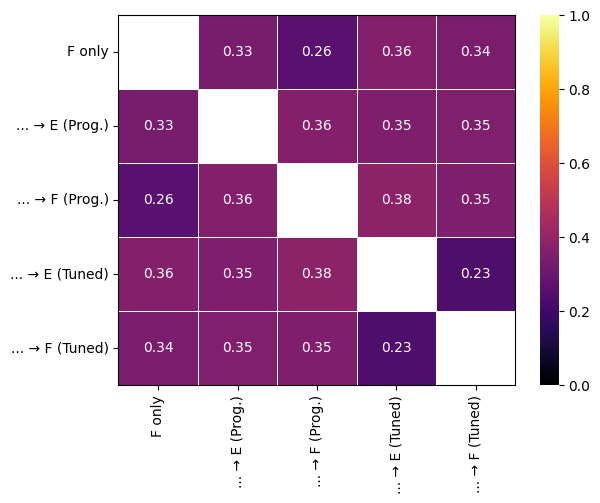

c:\Users\Thoma\OneDrive\Documenten\GitHub\vgc-bench\.venv\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


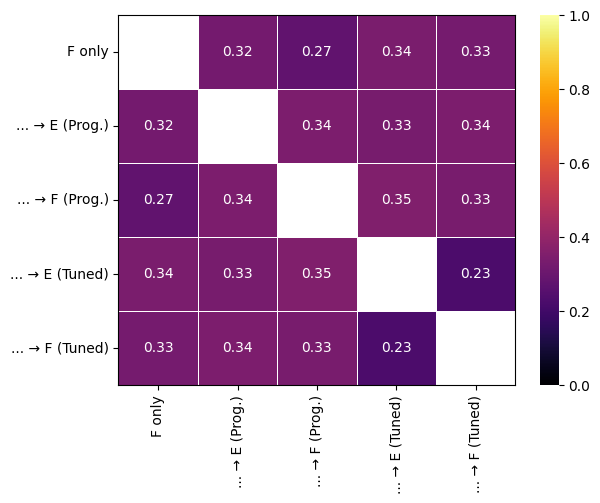

c:\Users\Thoma\OneDrive\Documenten\GitHub\vgc-bench\.venv\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


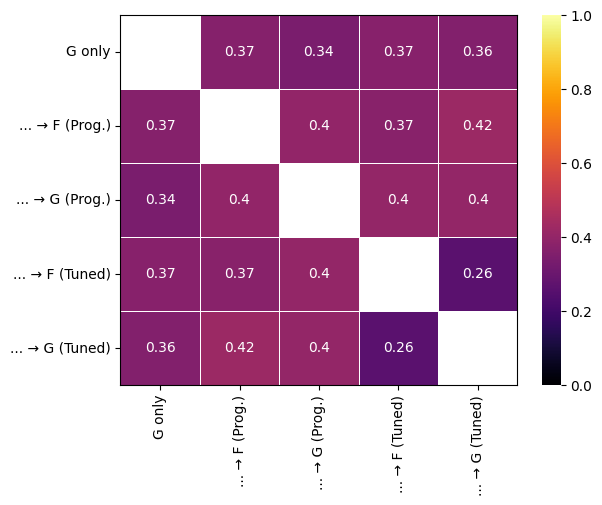

c:\Users\Thoma\OneDrive\Documenten\GitHub\vgc-bench\.venv\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


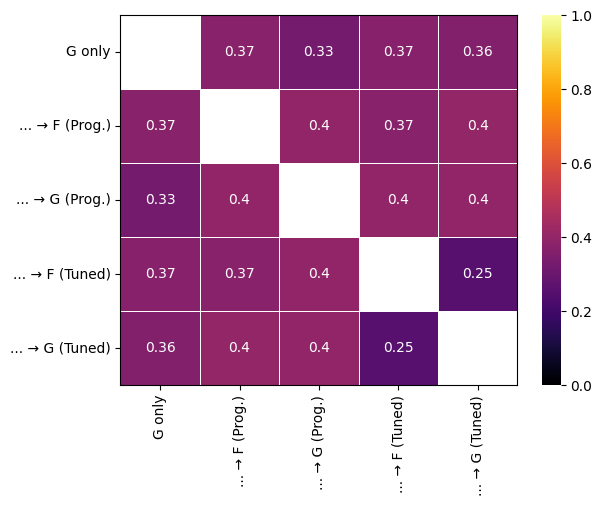

In [36]:
# mean js distance between action probs
def mean_dist_action(df, labels, reg, in_dist):
    distance_matrix = np.identity(len(labels))
    for i in range(len(labels)):
        for j in range(i):
            distance_matrix[i][j] = np.array([l for l in filter(lambda v: v==v, np.concat((
                np.array([
                    jensenshannon(df[f"action1_{i}"].values[k].clip(0,1), df[f"action1_{j}"].values[k].clip(0,1))
                for k in range(len(df))]),
                np.array([
                    jensenshannon(df[f"action2_{i}"].values[k].clip(0,1), df[f"action2_{j}"].values[k].clip(0,1))
                for k in range(len(df))])
            )))]).mean()
    distance_matrix = distance_matrix + distance_matrix.T
    np.fill_diagonal(distance_matrix, np.nan)

    ax = sns.heatmap(
        distance_matrix,
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2g",
        cmap="inferno",
        linewidth=0.5,
        xticklabels=[l.replace("Progressive", "Prog.") for l in labels],
        yticklabels=[l.replace("Progressive", "Prog.") for l in labels]
    )
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    plt.show()

plt.style.use('default')
mean_dist_action(df_f_indist, agent_map_f, "F", True)
mean_dist_action(df_f_outdist, agent_map_f, "F", False)
mean_dist_action(df_g_indist, agent_map_g, "G", True)
mean_dist_action(df_g_outdist, agent_map_g, "G", False)

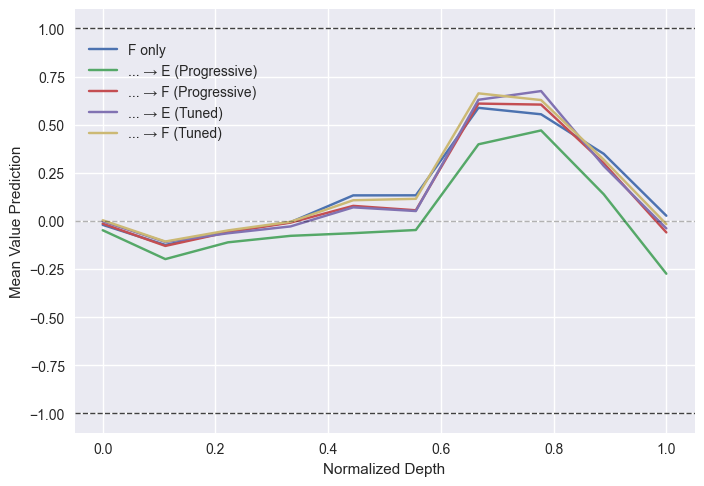

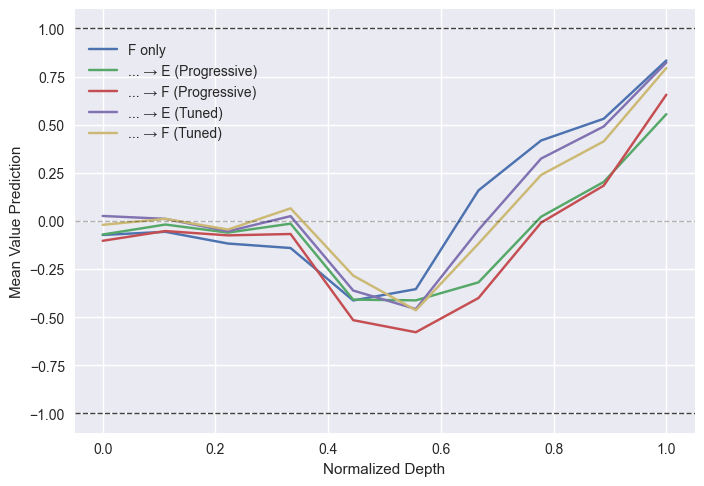

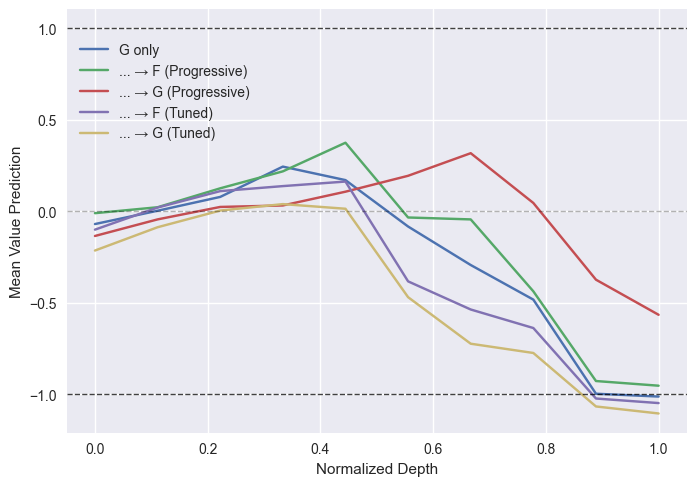

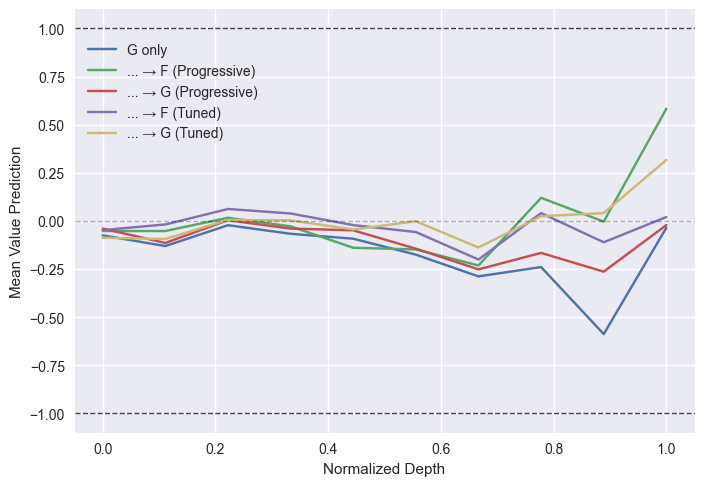

In [38]:
def mean_val_depth(df: pd.DataFrame, labels, reg, in_dist):
    n_points = 10
    depths = np.linspace(0, 1, num=n_points, endpoint=True)
    for i in range(len(labels)):
        plt.plot(
            depths,
            [df[(d <= df["progress"]) & (df["progress"] <= d+(1 / n_points))][f"value_{i}"].mean() for d in depths],
            label=labels[i]
        )
    plt.xlabel("Normalized Depth")
    plt.ylabel("Mean Value Prediction")
    plt.axhline(y=0, linestyle='--', linewidth=1, color=(0, 0, 0, 0.3))
    plt.axhline(y=-1, linestyle='--', linewidth=1, color=(0, 0, 0, 0.75))
    plt.axhline(y=1, linestyle='--', linewidth=1, color=(0, 0, 0, 0.75))
    plt.legend(loc=1, bbox_to_anchor=(0.315,0.95))
    plt.show()

plt.style.use('seaborn-v0_8')
mean_val_depth(df_f_indist, agent_map_f, "F", True)
mean_val_depth(df_f_outdist, agent_map_f, "F", False)
mean_val_depth(df_g_indist, agent_map_g, "G", True)
mean_val_depth(df_g_outdist, agent_map_g, "G", False)

## t-SNE

In [39]:
RANDOM_STATE = 42

def tnse_encode(df: pd.DataFrame) -> np.ndarray:
    X = np.vstack([np.array([i for i in df[c].to_numpy()]).squeeze(1) for c in df.columns])

    # PCA preprocessing
    pca = PCA(n_components=50, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=RANDOM_STATE,
        verbose=1
    )
    return tsne.fit_transform(X_pca)

def filter_columns(df: pd.DataFrame, agents: list[int]) -> pd.DataFrame:
    mask = []
    for i in agents:
        mask.append(f"logits_{i}")
    return df[mask]

columns = [0, 3, 4] # [0, 1, 2] for progressive, [0, 3, 4] for tuned
tsne_f_indist = tnse_encode(filter_columns(df_f_indist, columns))
tsne_f_outdist = tnse_encode(filter_columns(df_f_outdist, columns))
tsne_g_indist = tnse_encode(filter_columns(df_g_indist, columns))
tsne_g_outdist = tnse_encode(filter_columns(df_g_outdist, columns))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2772 samples in 0.001s...
[t-SNE] Computed neighbors for 2772 samples in 0.060s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2772
[t-SNE] Computed conditional probabilities for sample 2000 / 2772
[t-SNE] Computed conditional probabilities for sample 2772 / 2772
[t-SNE] Mean sigma: 24.829641
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.621056
[t-SNE] KL divergence after 1000 iterations: 0.914396
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3063 samples in 0.000s...
[t-SNE] Computed neighbors for 3063 samples in 0.056s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3063
[t-SNE] Computed conditional probabilities for sample 2000 / 3063
[t-SNE] Computed conditional probabilities for sample 3000 / 3063
[t-SNE] Computed conditional probabilities for sample 3063 / 3063
[t-SNE] Mean sigma: 22.471775
[t-SNE] KL divergence after 250 iterations with early exaggerati

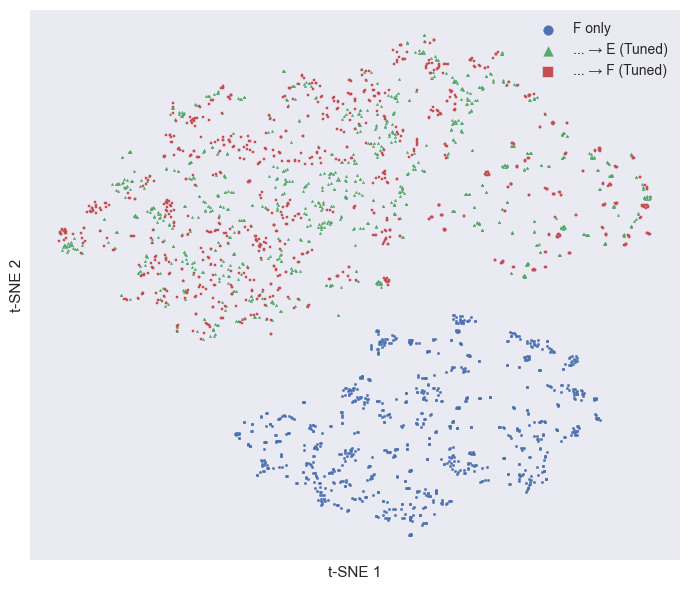

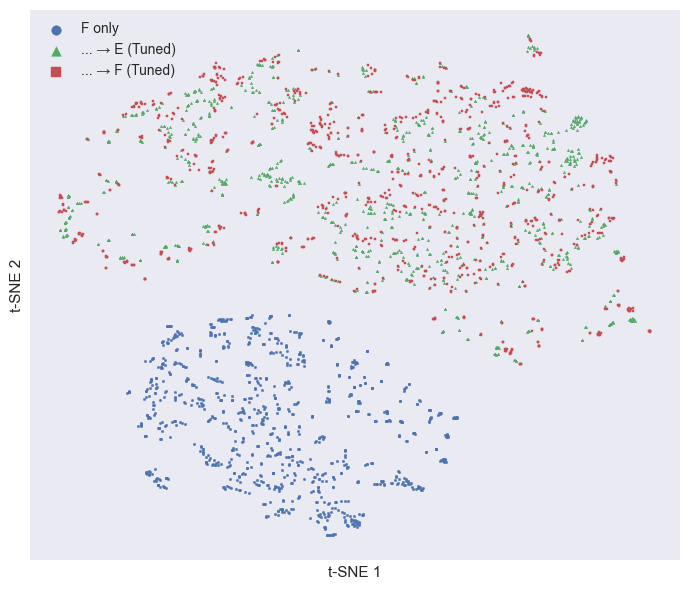

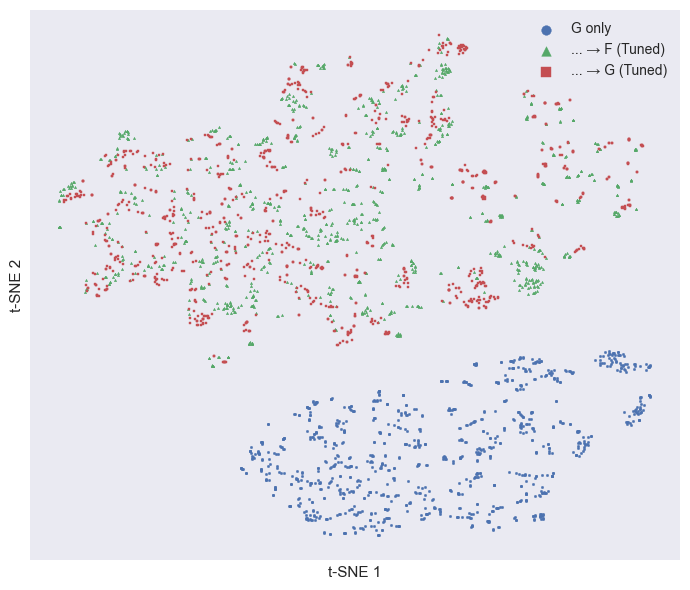

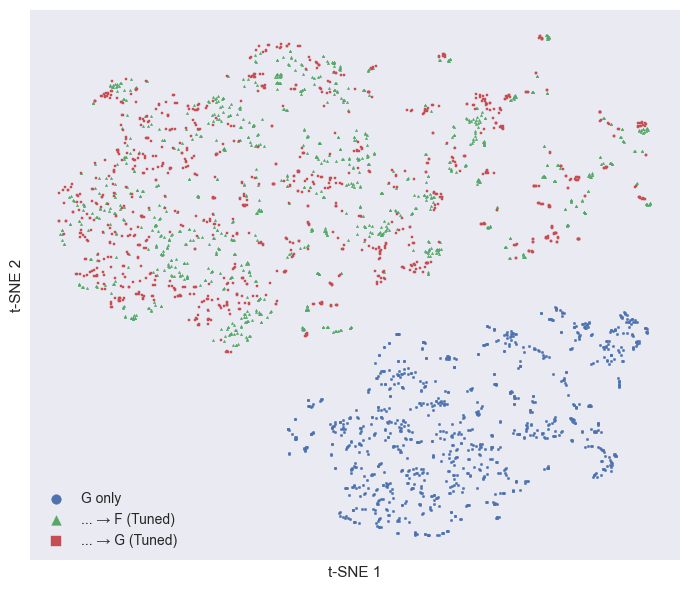

In [40]:
def plot_tnse(df:pd.DataFrame, X_tsne: np.ndarray, agent_map: list[str]):
    plt.figure(figsize=(7, 6))

    n = len(df)
    emb_0  = X_tsne[:n]
    emb_1 = X_tsne[n:2*n]
    emb_2  = X_tsne[2*n:]

    plt.scatter(emb_0[:, 0], emb_0[:, 1], s=3, marker='o', label=agent_map[columns[0]])
    plt.scatter(emb_1[:, 0], emb_1[:, 1], s=3, marker='^', label=agent_map[columns[1]])
    plt.scatter(emb_2[:, 0], emb_2[:, 1], s=3, marker='s', label=agent_map[columns[2]])

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

plt.style.use('seaborn-v0_8')
plot_tnse(df_f_indist, tsne_f_indist, agent_map_f)
plot_tnse(df_f_outdist, tsne_f_outdist, agent_map_f)
plot_tnse(df_g_indist, tsne_g_indist, agent_map_g)
plot_tnse(df_g_outdist, tsne_g_outdist, agent_map_g)

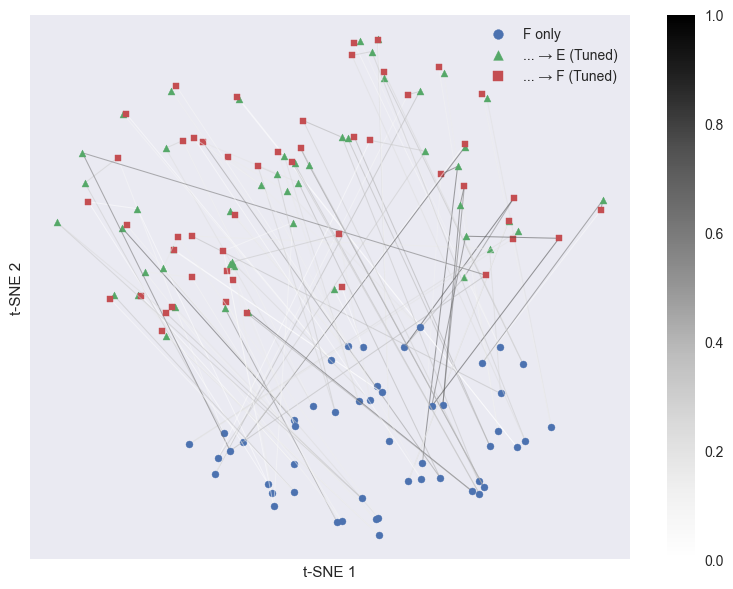

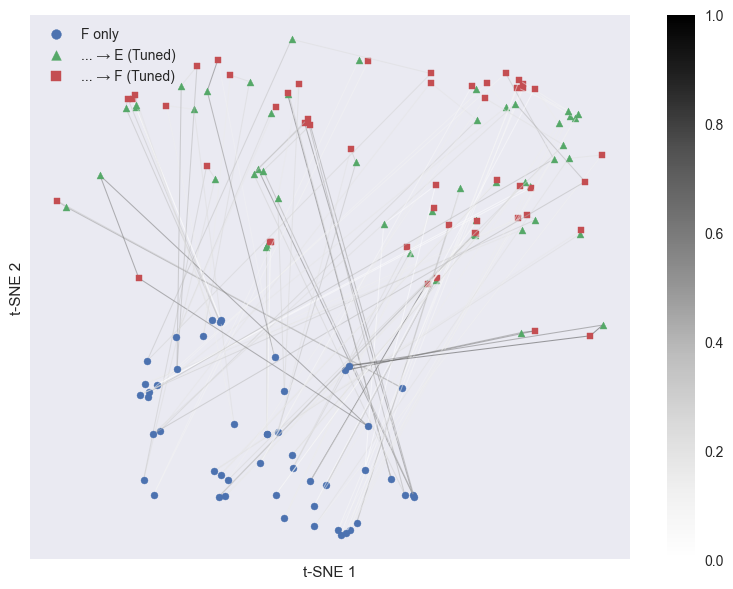

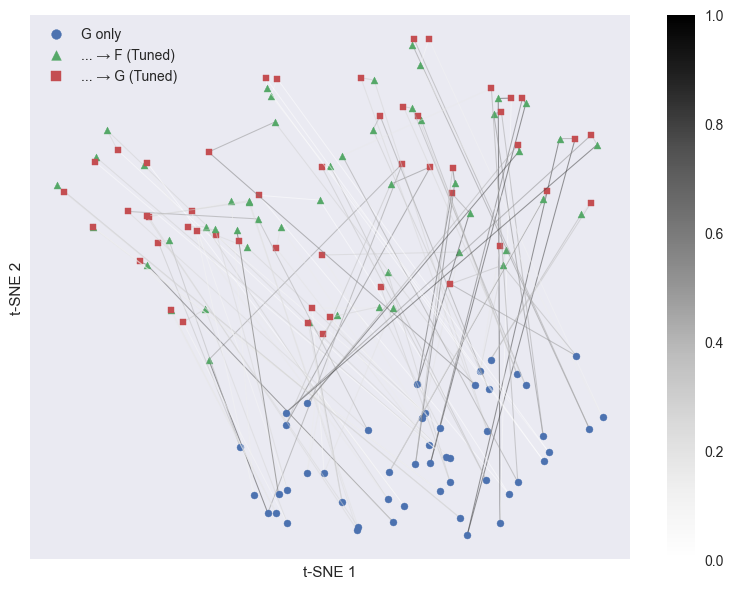

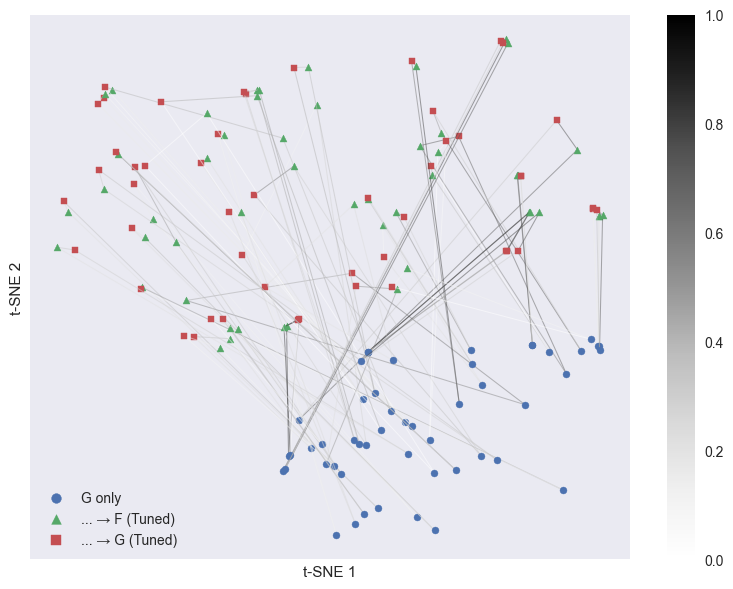

In [41]:
def plot_tnse(df: pd.DataFrame, X_tsne: np.ndarray, agent_map: list[str]):
    plt.figure(figsize=(8, 6))

    n = len(df)
    n_plot = 50
    idx = np.random.choice(n, n_plot, replace=False)

    emb_0  = X_tsne[:n]
    emb_1 = X_tsne[n:2*n]
    emb_2  = X_tsne[2*n:]

    cmap = plt.colormaps['Grays']
    colors = sns.color_palette(as_cmap=True)

    for j in idx:

        pts = np.vstack([
            emb_0[j],
            emb_1[j],
            emb_2[j]
        ])
        logits1 = np.array([i for i in df.iloc[j][[f"action1_{columns[0]}", f"action1_{columns[1]}", f"action1_{columns[2]}"]].to_numpy()])
        logits2 = np.array([i for i in df.iloc[j][[f"action2_{columns[0]}", f"action2_{columns[1]}", f"action2_{columns[2]}"]].to_numpy()])
        dists = (cdist(logits1, logits1, 'jensenshannon') + cdist(logits2, logits2, 'jensenshannon')) / 2

        # connect triplet
        plt.plot(
            pts[0:2,0],
            pts[0:2,1],
            c=cmap(dists[0,1]),
            alpha=0.5,
            linewidth=0.75,
            zorder=1
        )
        plt.plot(
            pts[1:3,0],
            pts[1:3,1],
            c=cmap(dists[0,2]),
            alpha=0.5,
            linewidth=0.75,
            zorder=1
        )
        plt.plot(
            pts[::2,0],
            pts[::2,1],
            c=cmap(dists[1,2]),
            alpha=0.5,
            linewidth=0.75,
            zorder=1
        )

        # draw points
        plt.scatter(*emb_0[j],  marker='o', color=colors[0], s=25)
        plt.scatter(*emb_1[j], marker='^', color=colors[1], s=25)
        plt.scatter(*emb_2[j],  marker='s', color=colors[2], s=25)

    # legend
    plt.scatter([], [], marker='o', color=colors[0], label=agent_map[columns[0]])
    plt.scatter([], [], marker='^', color=colors[1], label=agent_map[columns[1]])
    plt.scatter([], [], marker='s', color=colors[2], label=agent_map[columns[2]])
    plt.colorbar()

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.style.use('seaborn-v0_8')
plot_tnse(df_f_indist, tsne_f_indist, agent_map_f)
plot_tnse(df_f_outdist, tsne_f_outdist, agent_map_f)
plot_tnse(df_g_indist, tsne_g_indist, agent_map_g)
plot_tnse(df_g_outdist, tsne_g_outdist, agent_map_g)